## 1. Import Libraries

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score
)
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import RobustScaler, StandardScaler
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
from sklearn.decomposition import PCA
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from statsmodels.tools.tools import add_constant
from xgboost import XGBClassifier
import shap

## 2. Dataset Loading and Overview

In [2]:
# Read the csv file
df = pd.read_csv('bank-full.csv', delimiter=';').dropna().drop('duration', axis=1)

# Check missing values
missing_rows = df[df.isna().any(axis=1)]

if missing_rows.empty:
    print("No missing values found.")
else:
    print("Missing values found in rows:")
    print(missing_rows.index.tolist())

# Display data dimensions
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

# Display feature descriptions
display(df.describe())
display(df.describe(include="object"))

No missing values found.
The dataset has 45211 rows and 16 columns.


,age,balance,day,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,63.000000,871.000000,275.000000


,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


## 3. Exploratory Data Analysis

<Axes: ylabel='count'>

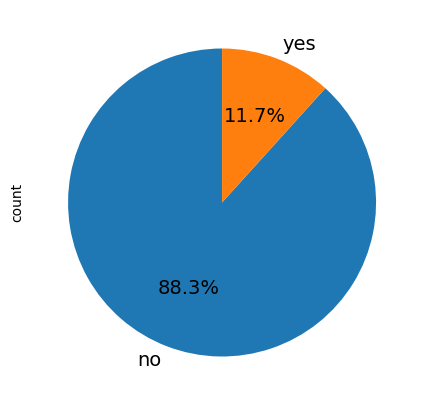

In [ ]:
#  Count the frequency of each class ('yes' vs 'no') in the target column
y_counts = df['y'].value_counts()

# Create the pie chart
y_counts.plot.pie(autopct='%1.1f%%', startangle=90, figsize=(5, 5), textprops={'fontsize': 14})
#plt.ylabel('')  # Optional: Remove default ylabel


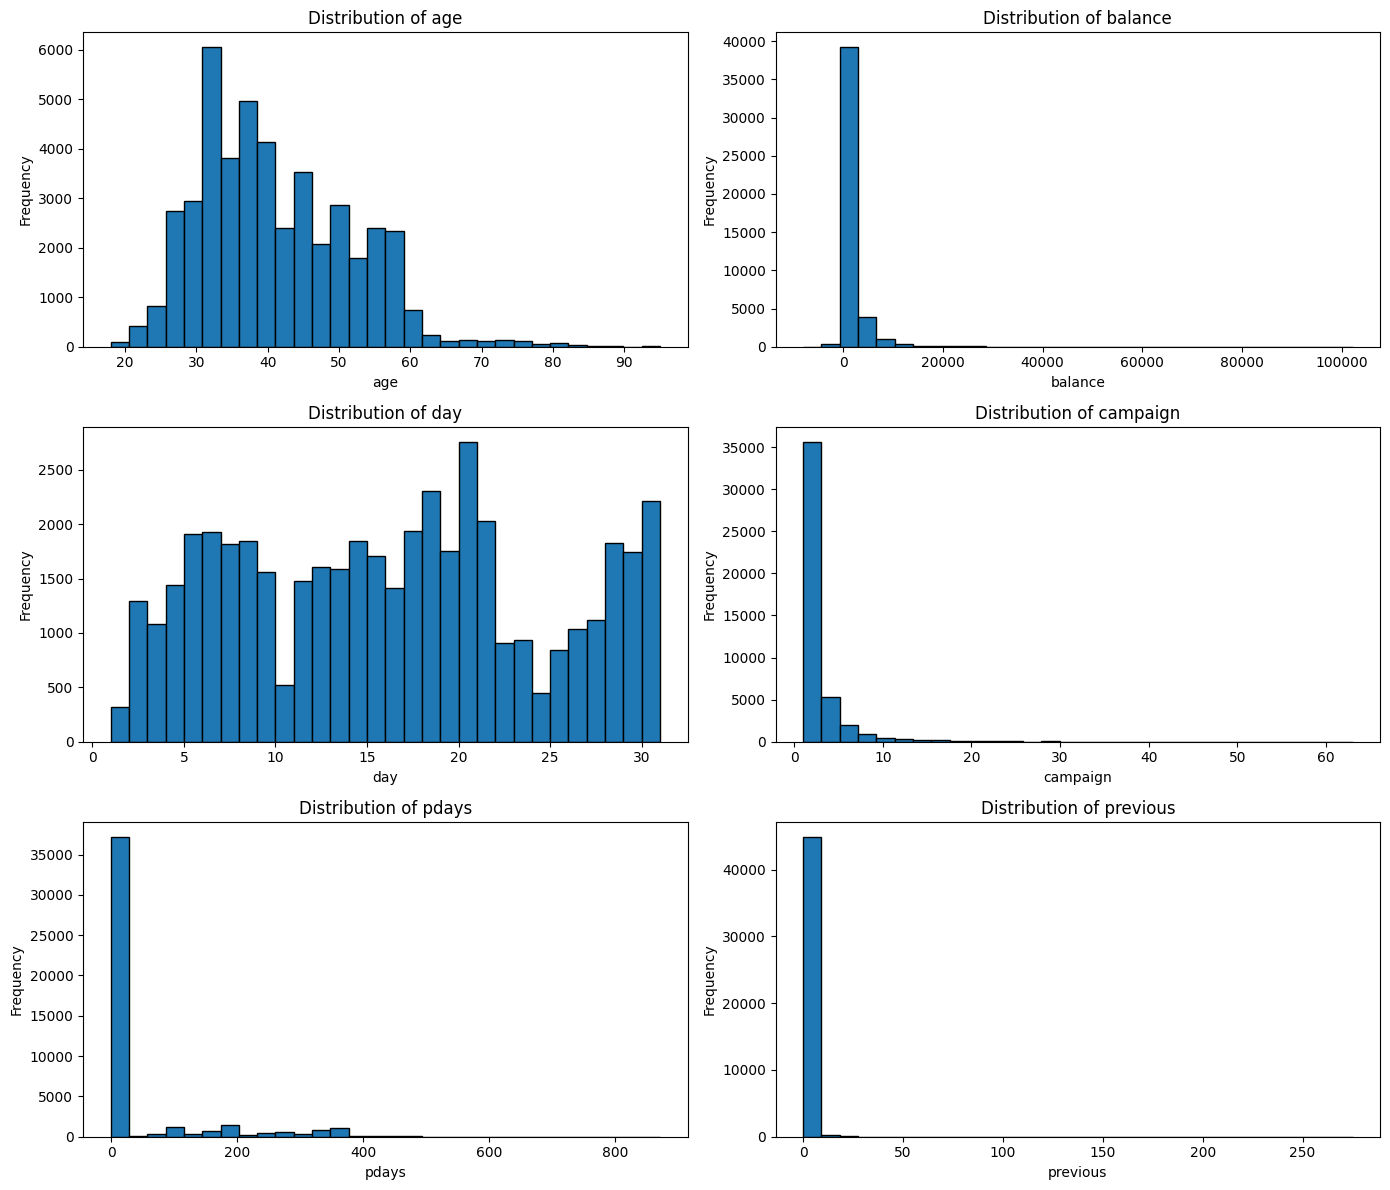

In [3]:
# ----------------------------------
# Histagrams of numberical features
# ----------------------------------
numerical_features = [
    "age",
    "balance",
    "day",
    "campaign",
    "pdays",
    "previous",
]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for feature, ax in zip(numerical_features, axes):
    ax.hist(df[feature], bins=30, edgecolor="black")
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

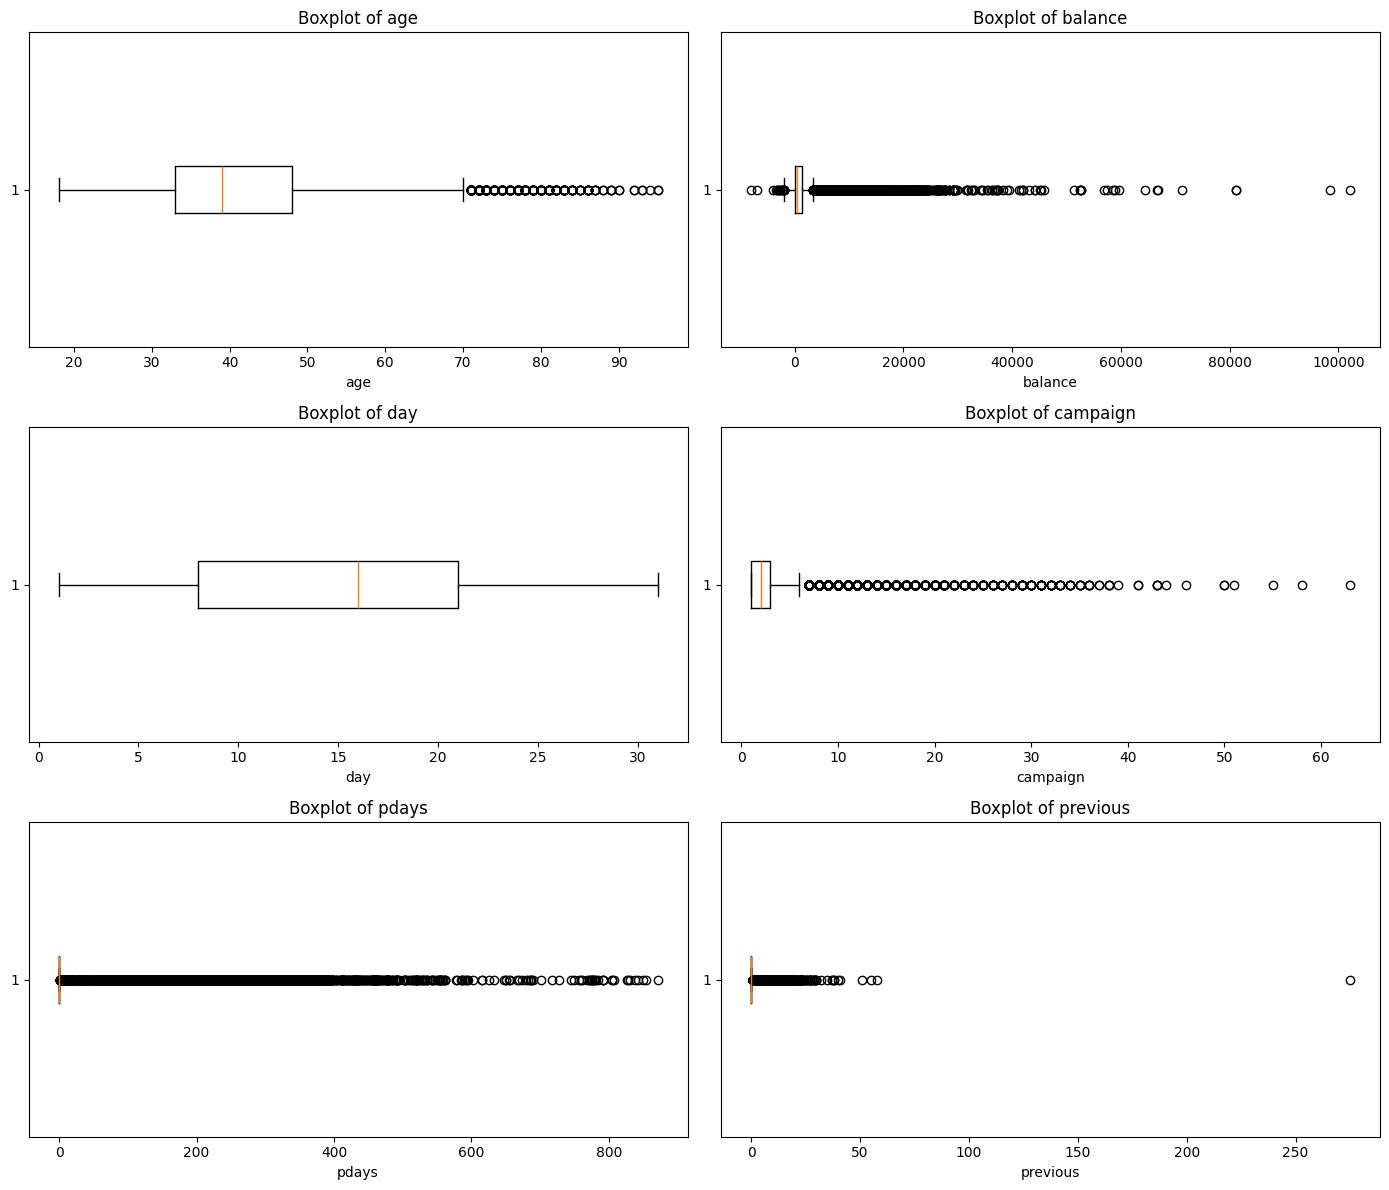

In [4]:
# ----------------------------------
# Boxplots of numberical features
# ----------------------------------
n_rows = 3
n_cols = 2

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, 12)
)

axes = axes.flatten()

for feature, ax in zip(numerical_features, axes):
    ax.boxplot(
        df[feature].dropna(),
        vert=False
    )
    ax.set_title(f"Boxplot of {feature}")
    ax.set_xlabel(feature)

# Hide unused axes if fewer than six variables are present.
for ax in axes[len(numerical_features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

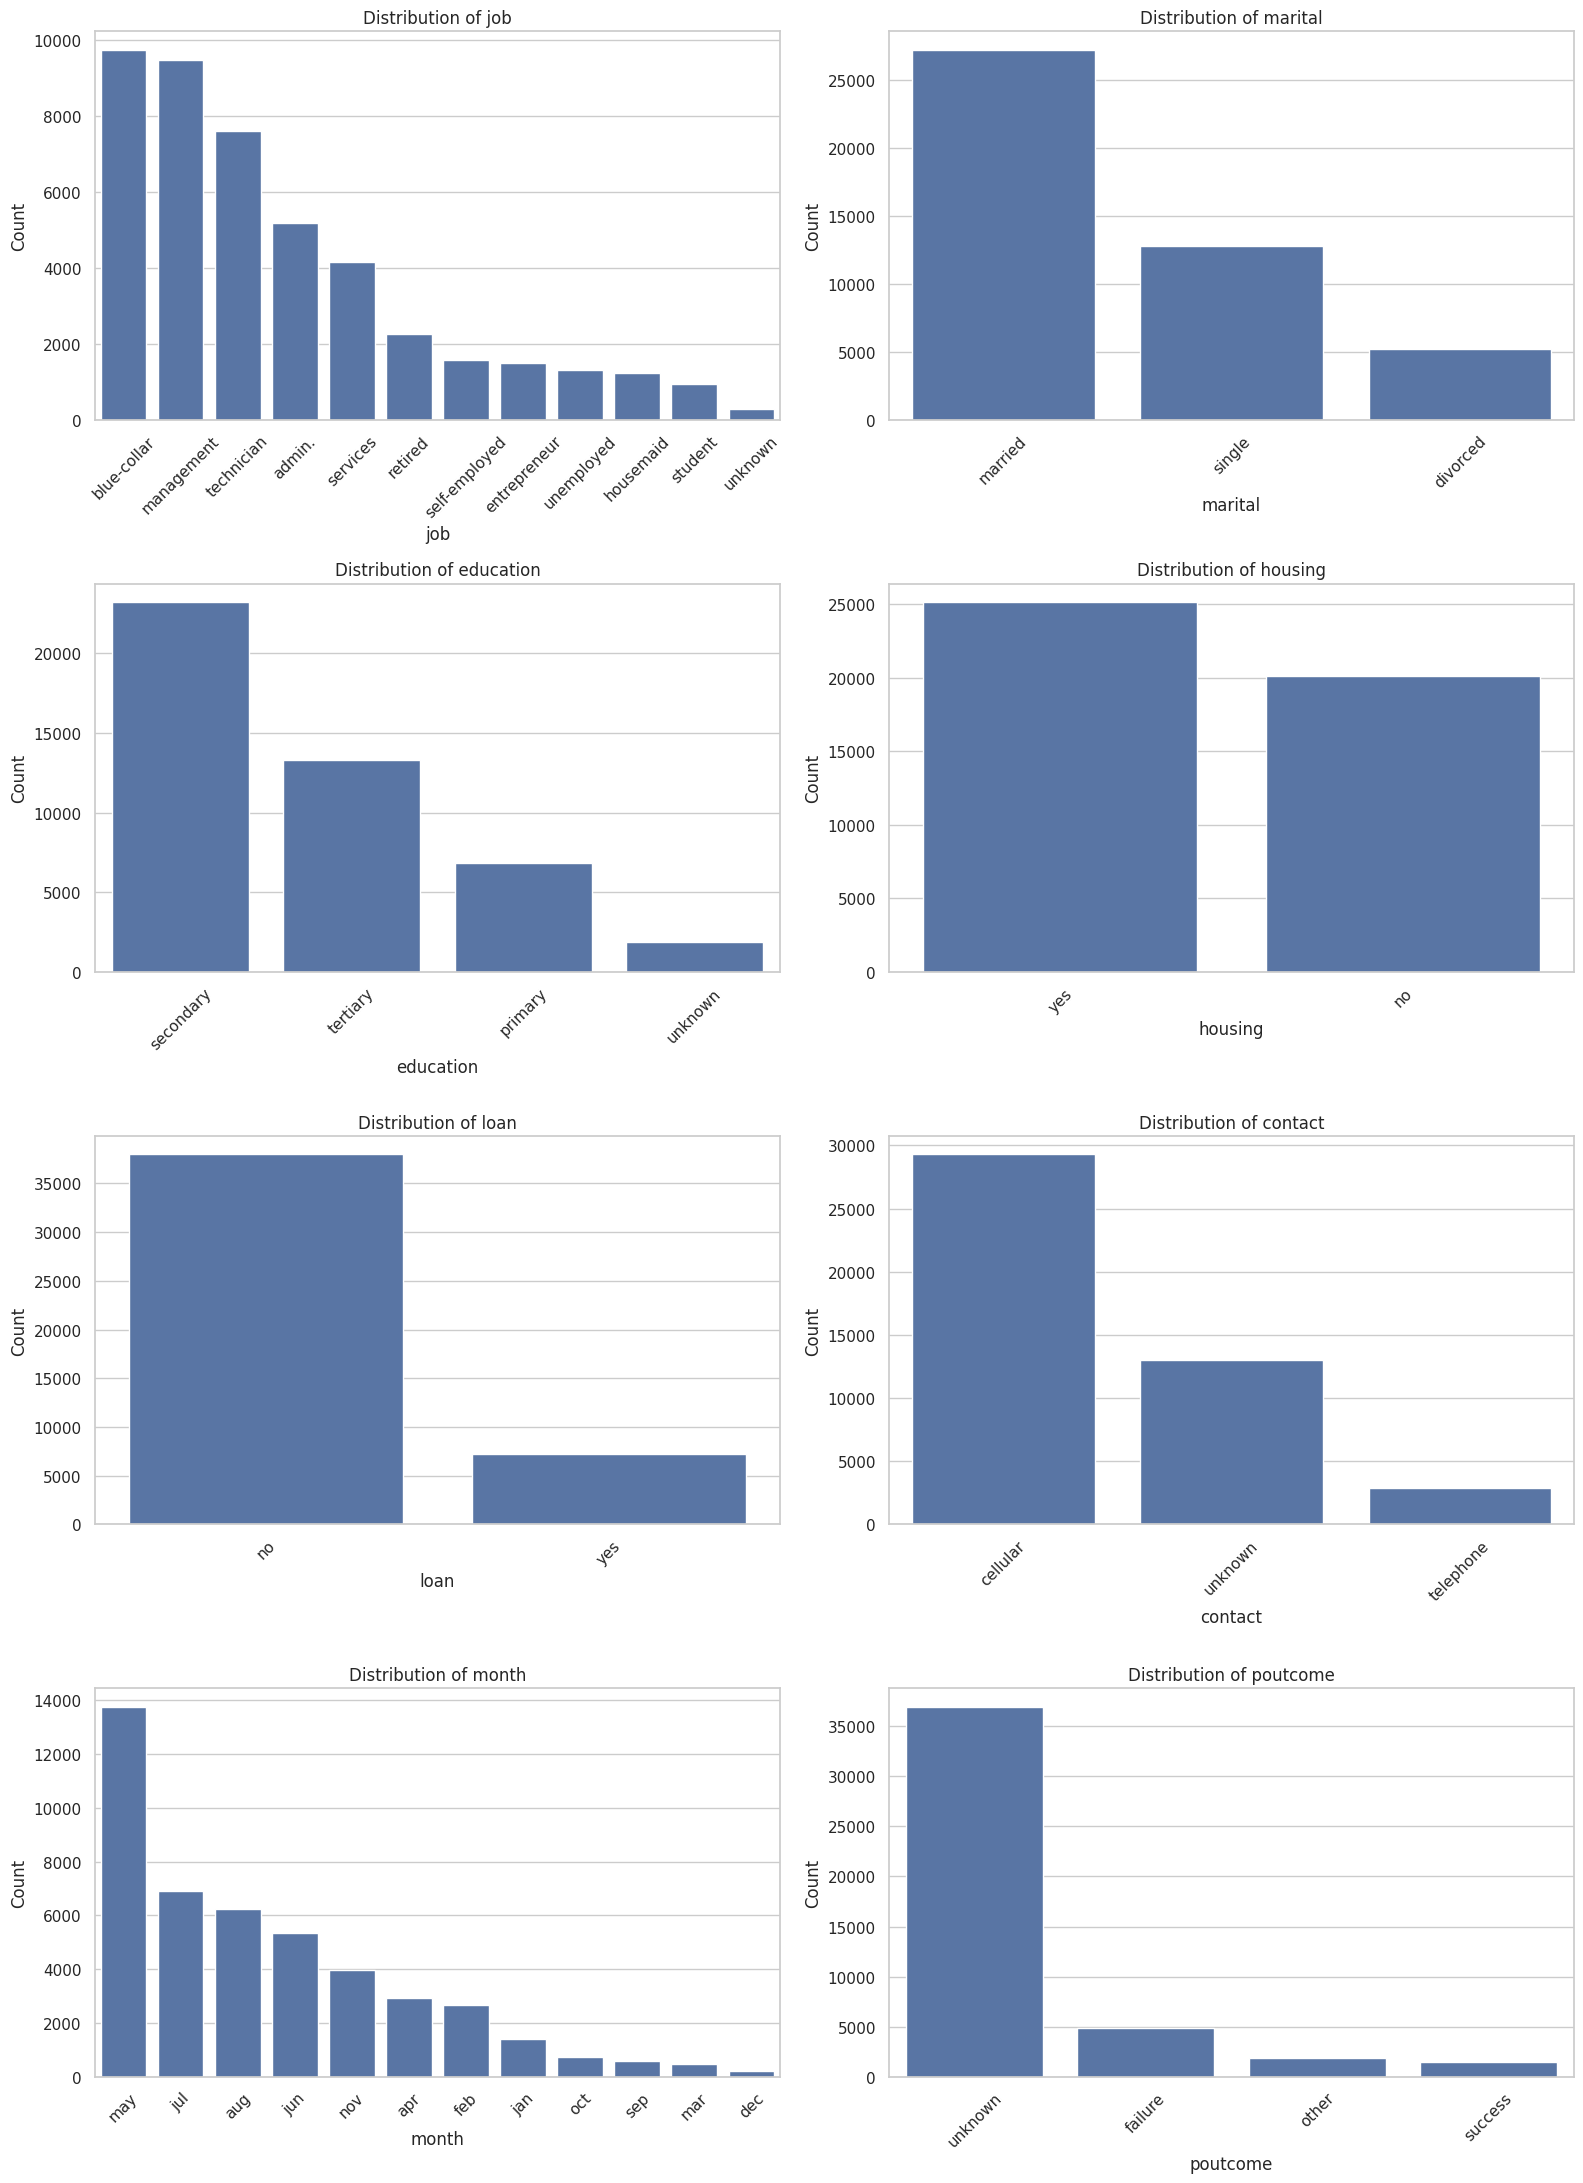

In [5]:
# -----------------------------
# Categorical features
# -----------------------------

categorical_features = [
    "job",
    "marital",
    "education",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome",
]

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.flatten()

for feature, ax in zip(categorical_features, axes):
    # Arrange categories from most common to least common.
    category_order = df[feature].value_counts().index

    sns.countplot(
        data=df,
        x=feature,
        order=category_order,
        ax=ax,
    )

    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

# Hide unused plots, if any.
for ax in axes[len(categorical_features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

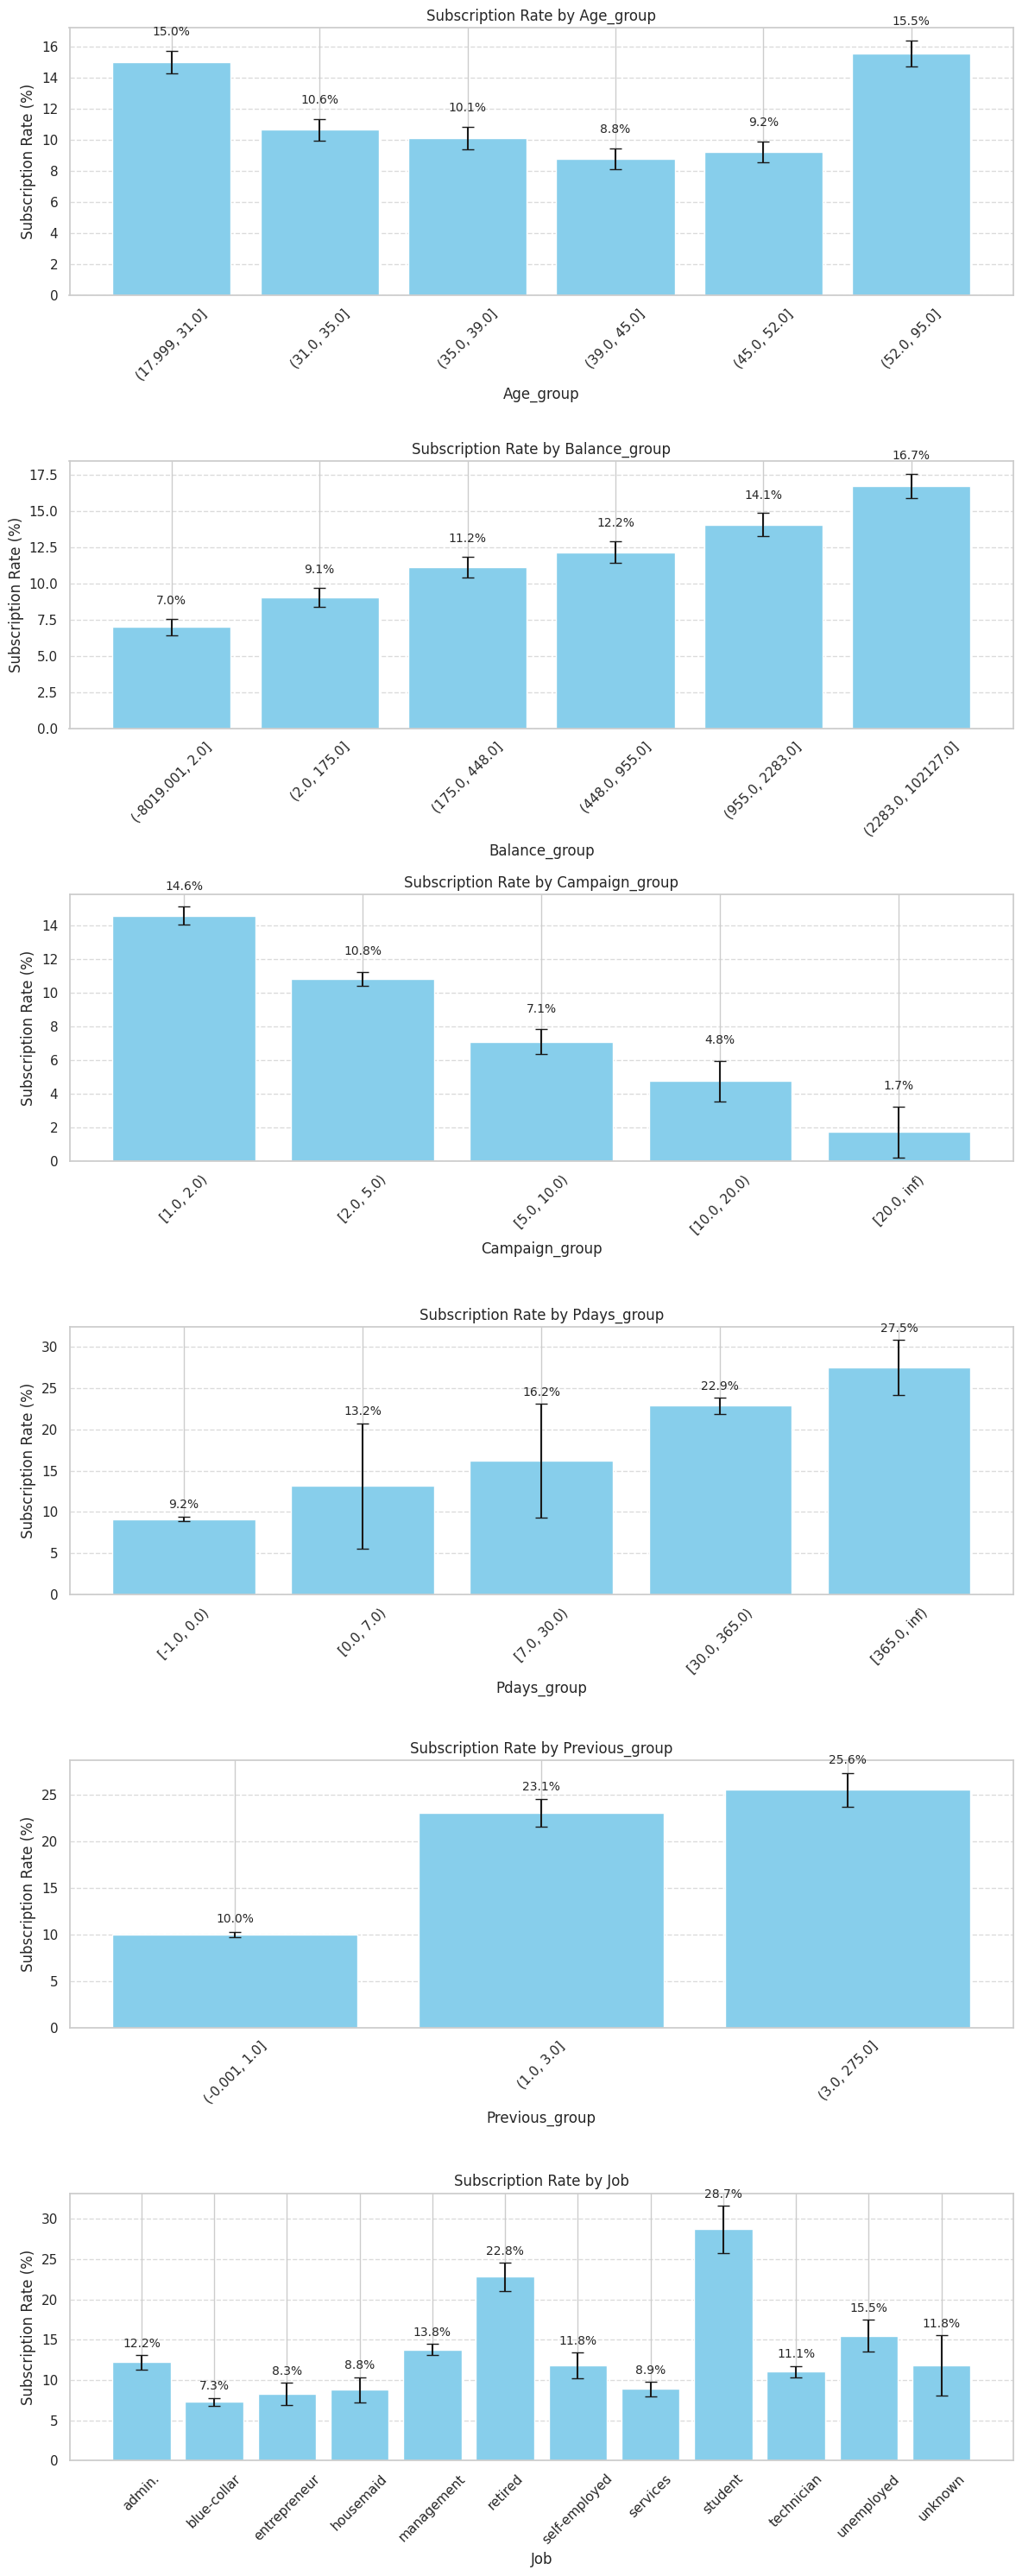

In [6]:
# -------------------------------
# Relationship with the target
# -------------------------------

df_copy = df.copy()
# Define confidence interval function
def confidence_interval(x):
    p_hat = (x == 'yes').mean()  # Sample proportion
    n = len(x)  # Sample size

    if n == 0:  # Avoid division by zero
        return 0, 0

    se = ((p_hat * (1 - p_hat)) / n) ** 0.5  # Standard error
    margin_of_error = stats.norm.ppf(0.975) * se  # 95% CI (Z = 1.96)

    return p_hat * 100, margin_of_error * 100  # Convert to percentages

# Bucket numerical features
df_copy['day_group'] = pd.cut(df['day'], bins = 15, duplicates = 'drop')
df_copy['age_group'] = pd.qcut(df['age'], q=6, duplicates='drop')
df_copy['balance_group'] = pd.qcut(df['balance'], q = 6, duplicates='drop')
df_copy['previous_group'] = pd.qcut(df['previous'], q = 15, duplicates='drop')

pdays_bins = [-1, 0, 7, 30, 365, float("inf")]  # Setting ranges
df_copy['pdays_group'] = pd.cut(df['pdays'], bins=pdays_bins, right=False)

campaign_bins = [1, 2, 5, 10, 20,  float("inf")]  # Setting ranges
df_copy['campaign_group'] = pd.cut(df['campaign'], bins=campaign_bins, right=False)

features = [
    "age_group",
    "balance_group",
    "campaign_group",
    "pdays_group",
    "previous_group",
] + categorical_features


fig, axes = plt.subplots(len(numerical_features), 1,
                         figsize=(12, 5 * len(numerical_features)))

for feature, ax in zip(features, axes):

    ci_results = (
        df.groupby(df_copy[feature], observed=True)["y"]
          .apply(confidence_interval)
          .apply(pd.Series)
    )
    ci_results.columns = [
        "subscription_rate",
        "margin_of_error"
    ]

    sub_rate = ci_results["subscription_rate"]
    error = ci_results["margin_of_error"]

    # Convert Interval objects to strings
    labels = sub_rate.index.astype(str)

    ax.bar(
        labels,
        sub_rate,
        yerr=error,
        capsize=5,
        color="skyblue"
    )

    # Add values above bars
    for i, (v, err) in enumerate(zip(sub_rate, error)):
        ax.text(
            i,
            v + err + 1,
            f"{v:.1f}%",
            ha="center",
            fontsize=10,
        )

    ax.set_title(f"Subscription Rate by {feature.capitalize()}")
    ax.set_xlabel(feature.capitalize())
    ax.set_ylabel("Subscription Rate (%)")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

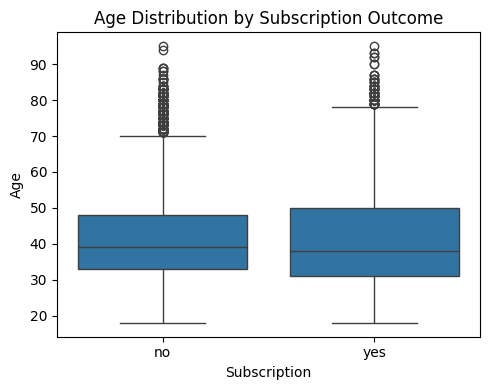

y,no,yes
housing,,
no,83.3,16.7
yes,92.3,7.7


In [ ]:
# Boxplot of age distribution by subscription outcome
plt.figure(figsize=(5, 4))

sns.boxplot(
    data=df,
    x="y",
    y="age"
)

plt.xlabel("Subscription")
plt.ylabel("Age")
plt.title("Age Distribution by Subscription Outcome")

plt.tight_layout()
plt.show()

# Calculate the proportion of "yes" and "no" within each job category.
job_target_table = pd.crosstab(
    df["housing"],
    df["y"],
    normalize="index"
)

# Convert proportions to percentages.
job_target_table = job_target_table * 100

# Sort jobs by subscription rate, if the "yes" column exists.
job_target_table = job_target_table.sort_values(
    by="yes",
    ascending=False
)

display(job_target_table.round(2))



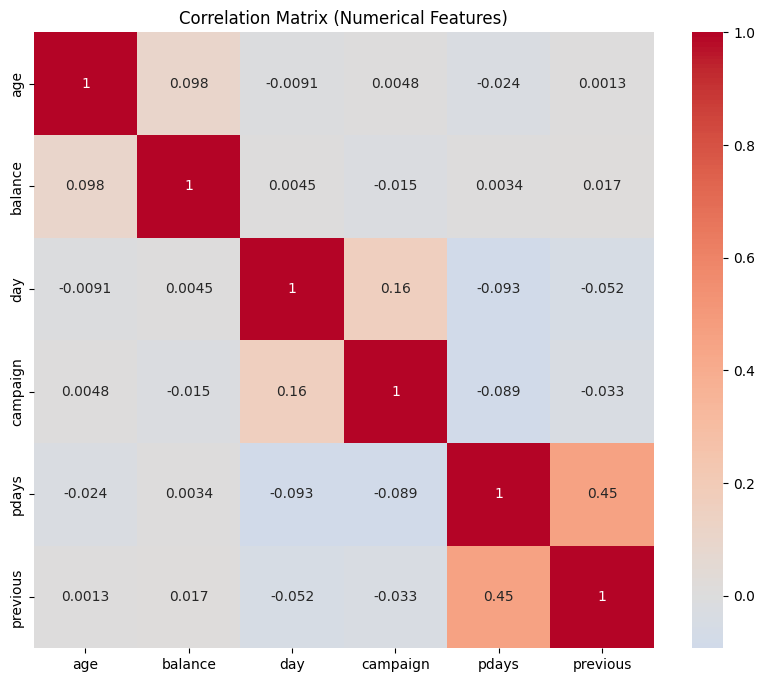

In [ ]:
# Correlation Matrix
numeric_cols = df.select_dtypes(include="number")

corr = numeric_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Numerical Features)")
plt.show()

## 4. Feature Selection

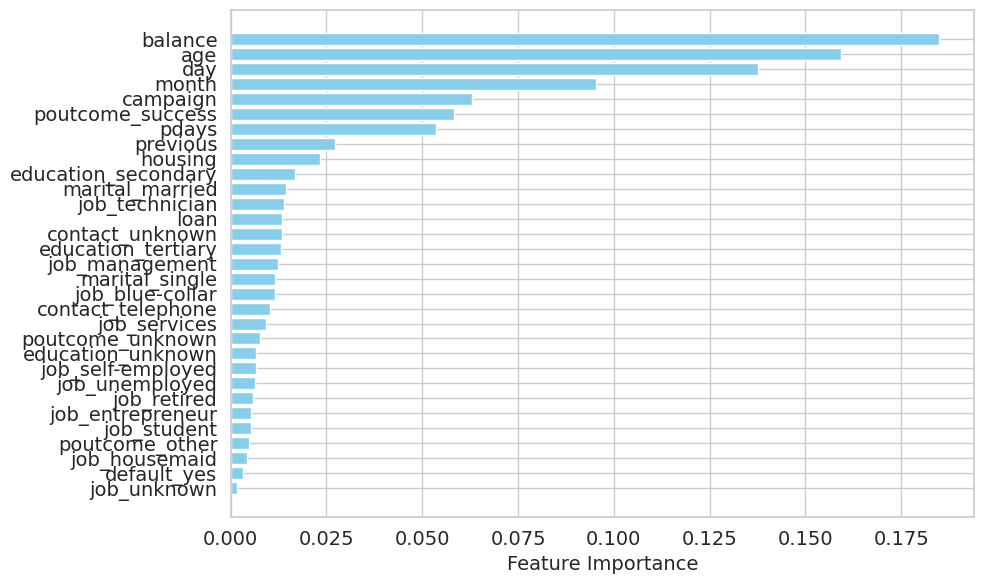

In [7]:
# Convert categorical variables into dummy variables
df_dummies = pd.get_dummies(df, columns=['job', 'marital', 'default',
                                          'education', 'contact', 'poutcome'], drop_first=True, dtype=int)

# Convert binary features to numerical values
df_dummies['y'] = df_dummies['y'].map({'yes': 1, 'no': 0})
df_dummies['housing'] = df_dummies['housing'].map({'yes': 1, 'no': 0})
df_dummies['loan'] = df_dummies['loan'].map({'yes': 1, 'no': 0})

# Convert month names to numbers
month_mapping = {'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
                 'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12}

df_dummies['month'] = df_dummies['month'].map(month_mapping)


# Separate features and target
X = df_dummies.drop('y', axis=1)
y = df_dummies['y']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Create a DataFrame for feature importances
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

# Sort all features by importance
features_df = features_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Get top feature names
top_5_features = features_df["Feature"].head(5).tolist()
top_10_features = features_df["Feature"].head(10).tolist()
top_20_features = features_df["Feature"].head(20).tolist()
all_features = X_train.columns.tolist()

# Create feature_sets dictionary
feature_sets = {
    "Top 5 Features": top_5_features,
    "Top 10 Features": top_10_features,
    "Top 20 Features": top_20_features,
    "All Features": all_features  # All features in X_train
}

# # Plot feature importances using a bar chart
plt.figure(figsize=(10, 6))
plt.barh(features_df['Feature'], features_df['Importance'], color='skyblue')
plt.xlabel('Feature Importance', fontsize = 14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature at the top
plt.show()

In [ ]:
# VIF
X_vif = add_constant(X)

vif_data = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_data = vif_data.sort_values(
    by="VIF",
    ascending=False
).reset_index(drop=True)

print(vif_data)

                Feature         VIF
0                 const  111.641112
1      poutcome_unknown    5.962424
2                 pdays    4.521011
3    education_tertiary    3.387135
4        job_management    3.021727
5        marital_single    2.879601
6   education_secondary    2.604114
7       marital_married    2.531333
8       job_blue-collar    2.504023
9        job_technician    2.092066
10                  age    1.716833
11          job_retired    1.697580
12         job_services    1.645791
13             previous    1.413031
14     poutcome_success    1.371570
15       poutcome_other    1.339161
16    job_self-employed    1.321855
17    education_unknown    1.303418
18     job_entrepreneur    1.301370
19        job_housemaid    1.286434
20      contact_unknown    1.258427
21          job_student    1.255099
22       job_unemployed    1.236980
23              housing    1.214643
24                month    1.114835
25          job_unknown    1.092524
26    contact_telephone    1

## 5. Model Selection

### 5.1 Logisitc Regression

In [ ]:
# Define 3-fold Stratified Cross-Validation
kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Hyperparameters to test
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"]
}


# Store results
cv_results = []


# Test each feature set
for feature_set_name, features in feature_sets.items():

    X_subset = X[features]

    model = LogisticRegression(
        solver="liblinear",
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    )

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=kf,
        scoring="f1",
        n_jobs=-1
    )

    grid_search.fit(X_subset, y)

    cv_results.append({
        "Feature Set": feature_set_name,
        "Best C": grid_search.best_params_["C"],
        "Best Penalty": grid_search.best_params_["penalty"],
        "Mean CV F1 Score": grid_search.best_score_
    })


# Convert results to a DataFrame
cv_results_df = pd.DataFrame(cv_results)

# Sort from best to worst
cv_results_df = cv_results_df.sort_values(
    by="Mean CV F1 Score",
    ascending=False
).reset_index(drop=True)

print(cv_results_df)

       Feature Set  Best C Best Penalty  Mean CV F1 Score
0     All Features   0.100           l1          0.339378
1  Top 20 Features   0.010           l1          0.335127
2  Top 10 Features   1.000           l2          0.305897
3   Top 5 Features   0.001           l1          0.233852


### 5.2 Random Forest

In [8]:
# Define 3-fold Stratified Cross-Validation
kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Hyperparameters to test
param_grid = {
    "n_estimators": [100, 200, 500],
        "max_depth": [None, 10, 20]
        }

# Store results
cv_results = []


# Test each feature set
for feature_set_name, features in feature_sets.items():

    X_subset = X[features]

    # Define Random Forest model
    model = RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    # Perform grid search
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=kf,
        scoring="f1",
        n_jobs=1,
        verbose=1
    )

    grid_search.fit(X_subset, y)

    # Store the best result for this feature set
    cv_results.append({
        "Feature Set": feature_set_name,
        "Best n_estimators":
            grid_search.best_params_["n_estimators"],
        "Best max_depth":
            grid_search.best_params_["max_depth"],
        "Mean CV F1 Score":
            grid_search.best_score_
    })


# Convert results to a DataFrame
cv_results_df = pd.DataFrame(cv_results)


# Sort from best to worst
cv_results_df = cv_results_df.sort_values(
    by="Mean CV F1 Score",
    ascending=False
).reset_index(drop=True)


print(cv_results_df)

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Fitting 3 folds for each of 9 candidates, totalling 27 fits
Fitting 3 folds for each of 9 candidates, totalling 27 fits
       Feature Set  Best n_estimators  Best max_depth  Mean CV F1 Score
0  Top 10 Features                500              10          0.458721
1  Top 20 Features                100              10          0.434636
2     All Features                500              10          0.433119
3   Top 5 Features                200              10          0.392139


### 5.3 Naive Bayes

In [ ]:
# Define 3-fold Stratified Cross-Validation
kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Hyperparameters to test
param_grid = {
    "var_smoothing": np.logspace(-12, -6, 7)
}

# Store results
cv_results = []


# Test each feature set
for feature_set_name, features in feature_sets.items():

    X_subset = X[features]

    # Define Naive Bayes model
    model = GaussianNB()

    # Perform grid search
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=kf,
        scoring="f1",
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_subset, y)

    # Store the best result for this feature set
    cv_results.append({
        "Feature Set": feature_set_name,
        "Best var_smoothing":
            grid_search.best_params_["var_smoothing"],
        "Mean CV F1 Score":
            grid_search.best_score_
    })


# Convert results to a DataFrame
cv_results_df = pd.DataFrame(cv_results)


# Sort from best to worst
cv_results_df = cv_results_df.sort_values(
    by="Mean CV F1 Score",
    ascending=False
).reset_index(drop=True)


print(cv_results_df)

Fitting 3 folds for each of 7 candidates, totalling 21 fits
Fitting 3 folds for each of 7 candidates, totalling 21 fits
Fitting 3 folds for each of 7 candidates, totalling 21 fits
Fitting 3 folds for each of 7 candidates, totalling 21 fits
       Feature Set  Best var_smoothing  Mean CV F1 Score
0     All Features        1.000000e-09          0.338631
1  Top 20 Features        1.000000e-10          0.332359
2  Top 10 Features        1.000000e-08          0.317662
3   Top 5 Features        1.000000e-12          0.107152


### 5.4 XGBoost

In [ ]:
# Define 3-fold Stratified Cross-Validation
kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Hyperparameters to test
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7]
}

# Store results
cv_results = []


# Test each feature set
for feature_set_name, features in feature_sets.items():

    X_subset = X[features]

    # Define XGBoost model
    model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=1
    )

    # Perform grid search
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=kf,
        scoring="f1",
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_subset, y)

    # Store the best result for this feature set
    cv_results.append({
        "Feature Set": feature_set_name,
        "Best n_estimators":
            grid_search.best_params_["n_estimators"],
        "Best learning_rate":
            grid_search.best_params_["learning_rate"],
        "Best max_depth":
            grid_search.best_params_["max_depth"],
        "Mean CV F1 Score":
            grid_search.best_score_
    })


# Convert results to a DataFrame
cv_results_df = pd.DataFrame(cv_results)


# Sort from best to worst
cv_results_df = cv_results_df.sort_values(
    by="Mean CV F1 Score",
    ascending=False
).reset_index(drop=True)


print(cv_results_df)

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Fitting 3 folds for each of 27 candidates, totalling 81 fits
Fitting 3 folds for each of 27 candidates, totalling 81 fits
       Feature Set  Best n_estimators  Best learning_rate  Best max_depth  \
0     All Features                300                 0.1               7   
1  Top 20 Features                300                 0.1               7   
2  Top 10 Features                300                 0.1               7   
3   Top 5 Features                300                 0.1               7   

   Mean CV F1 Score  
0          0.364358  
1          0.357878  
2          0.350737  
3          0.255061  


## 6. Final Model Evaluation

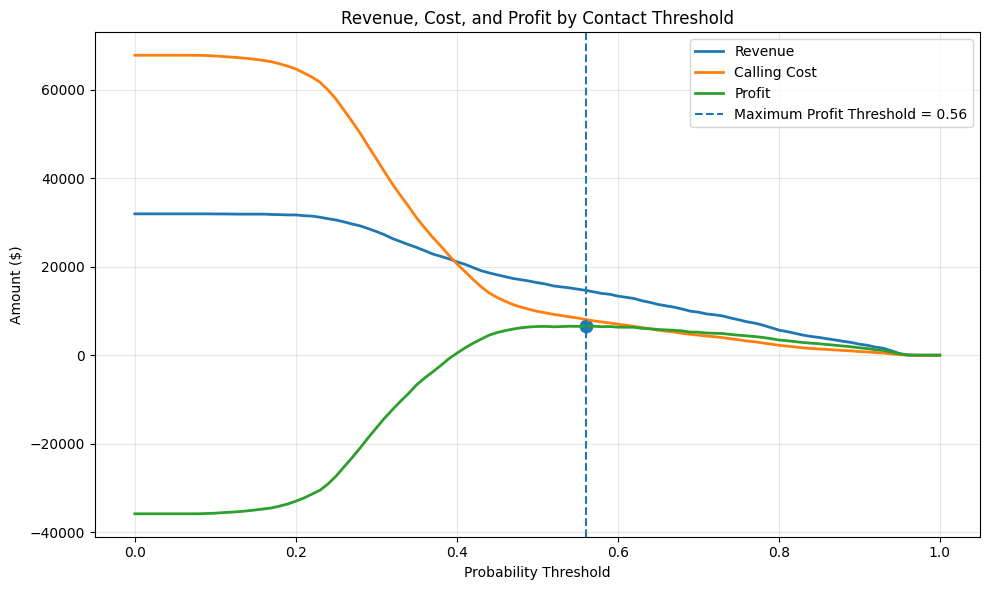

In [ ]:
# Set up and train the best model with the best hyperparameters
best_model = RandomForestClassifier(
    max_depth=10,
    n_estimators=500,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

X_train_subset = X_train[feature_sets["Top 10 Features"]]
X_test_subset = X_test[feature_sets["Top 10 Features"]]

best_model.fit(X_train_subset, y_train)

# Predicted classes: 0 or 1
y_pred = best_model.predict(X_test_subset)

# Predicted probabilities of class 1
y_prob = best_model.predict_proba(X_test_subset)[:, 1]

# Business assumptions
revenue_per_subscription = 20
cost_per_call = 5

# Probability thresholds to evaluate
thresholds = np.arange(0.00, 1.01, 0.01)

business_results = []

for threshold in thresholds:

    # Contact customers whose predicted probability is at least the threshold
    contacted = y_prob >= threshold

    # Total number of customers contacted
    number_contacted = contacted.sum()

    # Successful subscriptions among contacted customers
    successful_subscriptions = (
        (contacted) & (y_test.to_numpy() == 1)
    ).sum()

    # Financial calculations
    revenue = successful_subscriptions * revenue_per_subscription
    cost = number_contacted * cost_per_call
    profit = revenue - cost

    business_results.append({
        "Threshold": threshold,
        "Customers Contacted": number_contacted,
        "Successful Subscriptions": successful_subscriptions,
        "Revenue": revenue,
        "Cost": cost,
        "Profit": profit
    })


business_df = pd.DataFrame(business_results)

# Find the most profitable threshold
best_profit_row = business_df.loc[
    business_df["Profit"].idxmax()
]

plt.figure(figsize=(10, 6))

plt.plot(
    business_df["Threshold"],
    business_df["Revenue"],
    label="Revenue",
    linewidth=2
)

plt.plot(
    business_df["Threshold"],
    business_df["Cost"],
    label="Calling Cost",
    linewidth=2
)

plt.plot(
    business_df["Threshold"],
    business_df["Profit"],
    label="Profit",
    linewidth=2
)

# Mark the threshold with maximum profit
best_threshold = best_profit_row["Threshold"]
best_profit = best_profit_row["Profit"]

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Maximum Profit Threshold = {best_threshold:.2f}"
)

plt.scatter(
    best_threshold,
    best_profit,
    s=80
)

plt.xlabel("Probability Threshold")
plt.ylabel("Amount ($)")
plt.title("Revenue, Cost, and Profit by Contact Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

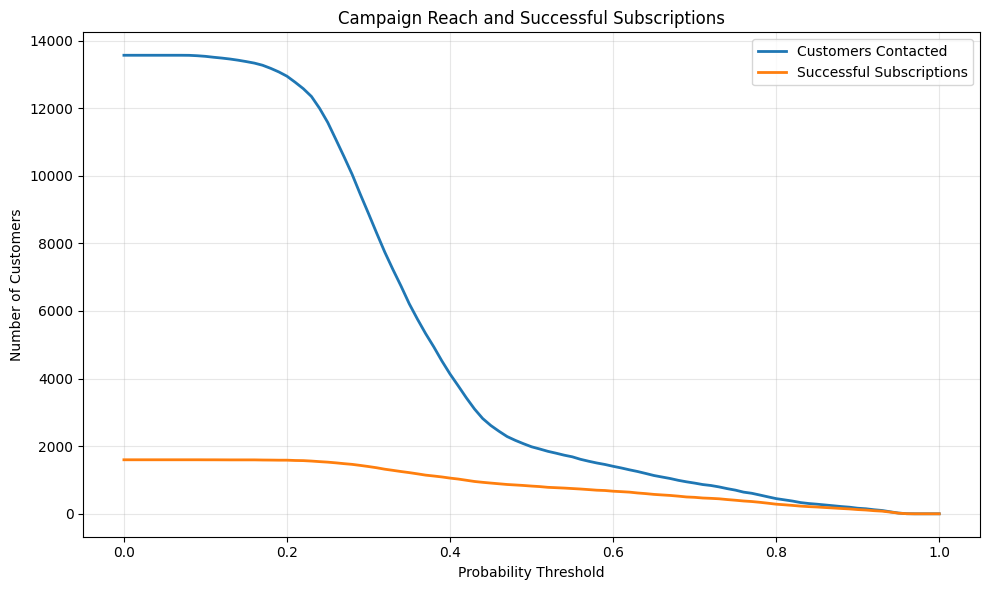

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    business_df["Threshold"],
    business_df["Customers Contacted"],
    label="Customers Contacted",
    linewidth=2
)

plt.plot(
    business_df["Threshold"],
    business_df["Successful Subscriptions"],
    label="Successful Subscriptions",
    linewidth=2
)

plt.xlabel("Probability Threshold")
plt.ylabel("Number of Customers")
plt.title("Campaign Reach and Successful Subscriptions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:

# Calculate test-set metrics
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(y_test, y_prob)


# Store results in a DataFrame
test_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Test Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

print(test_results)

      Metric  Test Score
0   Accuracy    0.856974
1  Precision    0.413724
2     Recall    0.513141
3   F1 Score    0.458101
4    ROC-AUC    0.766672


In [ ]:
# Confusion matrix & classification report
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No", "Yes"],
    digits=4,
    zero_division=0
))

Confusion Matrix:
[[10804  1162]
 [  778   820]]

Classification Report:
              precision    recall  f1-score   support

          No     0.9328    0.9029    0.9176     11966
         Yes     0.4137    0.5131    0.4581      1598

    accuracy                         0.8570     13564
   macro avg     0.6733    0.7080    0.6879     13564
weighted avg     0.8717    0.8570    0.8635     13564



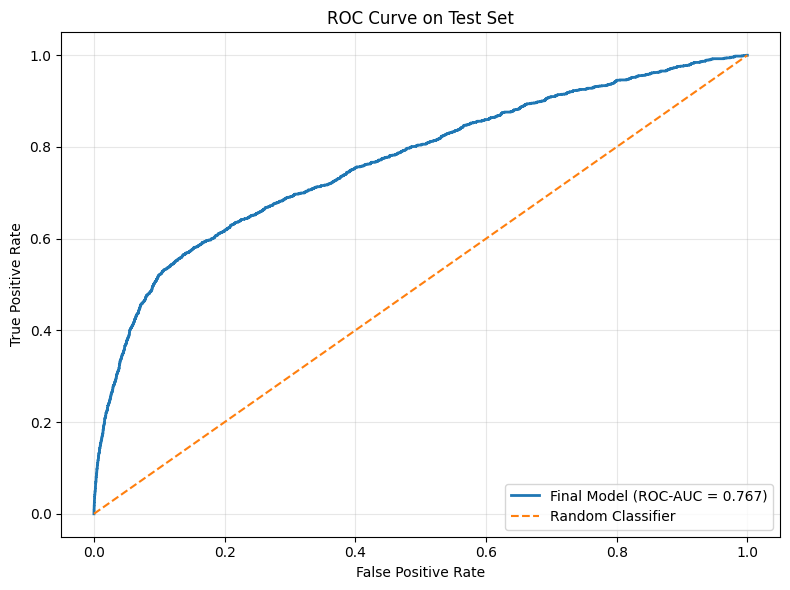

In [ ]:
# Calculate ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Final Model (ROC-AUC = {roc_auc:.3f})"
)

# Random-classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Set")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

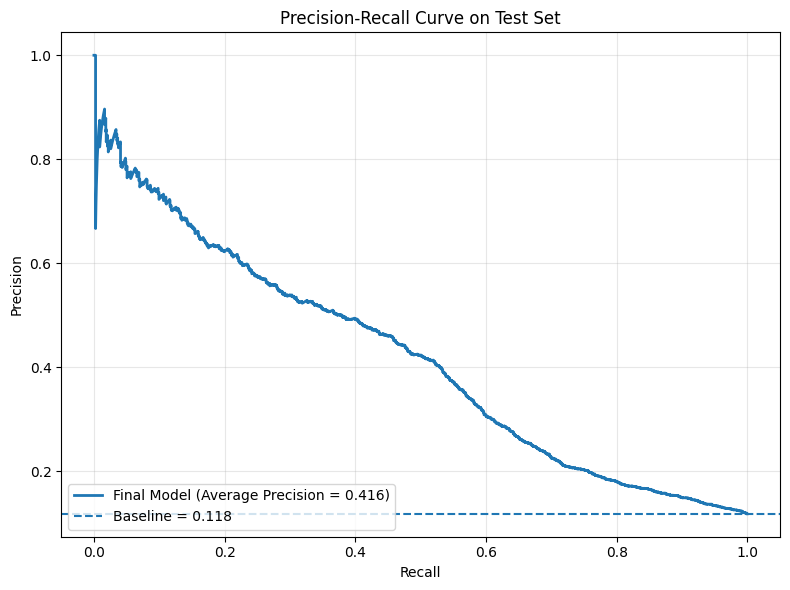

In [ ]:
# Precision-Recall Curve
# Calculate precision and recall at different thresholds
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)


# Calculate PR-AUC using average precision
average_precision = average_precision_score(
    y_test,
    y_prob
)


# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"Final Model (Average Precision = {average_precision:.3f})"
)

# Baseline: proportion of positive observations in the test set
positive_rate = y_test.mean()

plt.axhline(
    y=positive_rate,
    linestyle="--",
    label=f"Baseline = {positive_rate:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve on Test Set")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

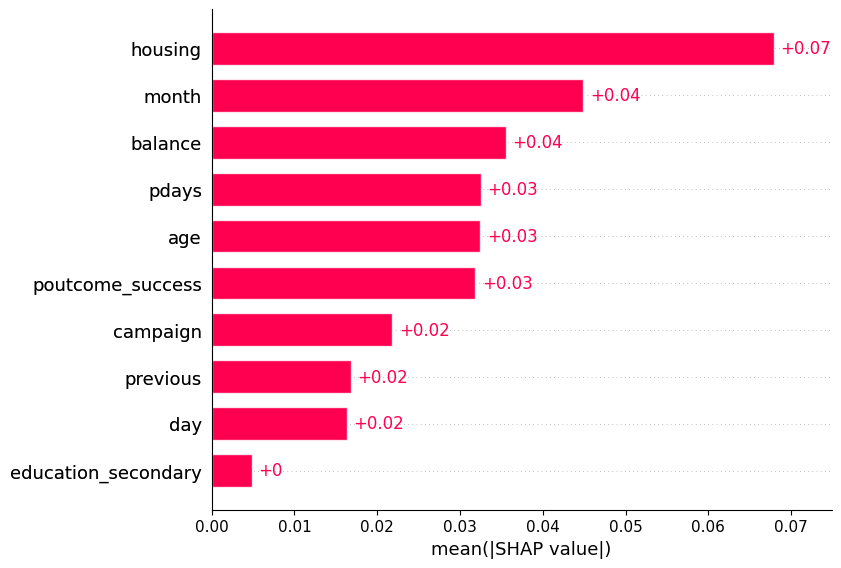

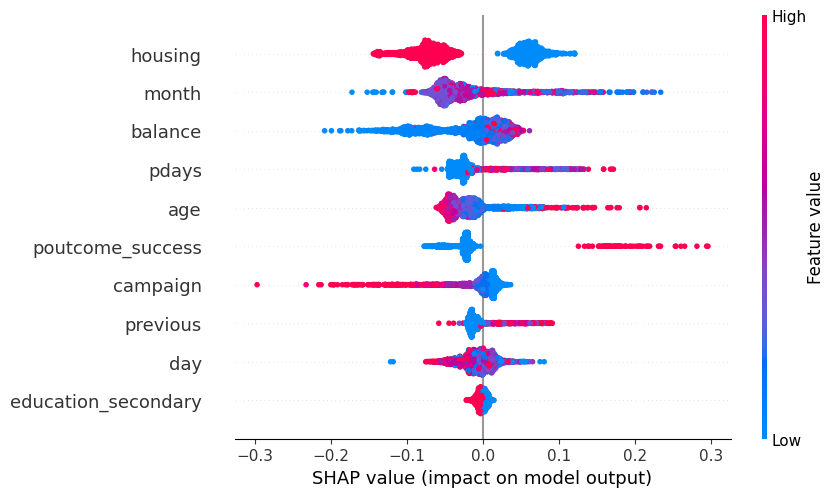

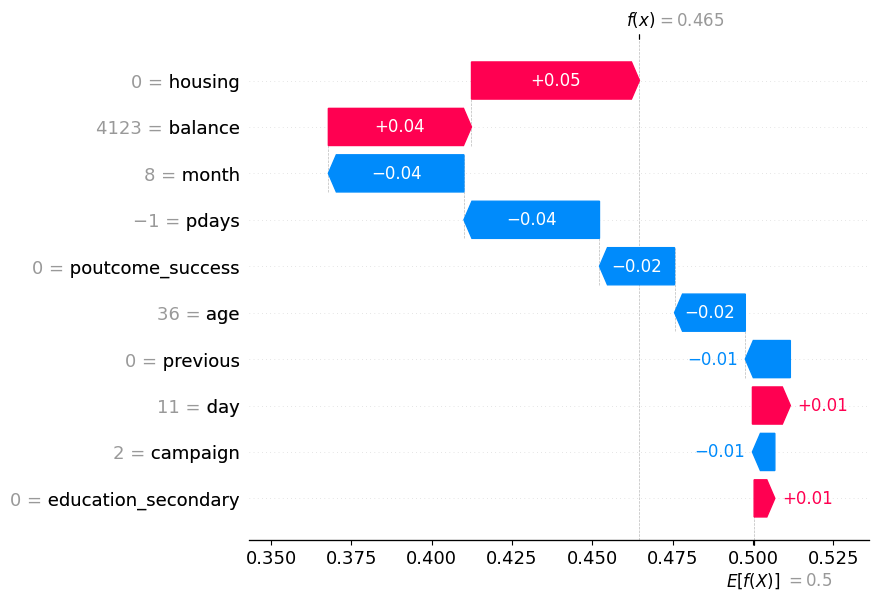

In [ ]:
# Use a sample to reduce computation time
X_shap = X_test_subset.sample(
    n=min(2000, len(X_test_subset)),
    random_state=42
)


# Create SHAP explainer
explainer = shap.TreeExplainer(best_model)


# Calculate SHAP values
shap_values = explainer(X_shap)


# Some classifiers return one explanation per class
if len(shap_values.shape) == 3:
    shap_values_plot = shap_values[:, :, 1]
else:
    shap_values_plot = shap_values


# Global importance
shap.plots.bar(
    shap_values_plot,
    max_display=15
)


# Global direction and distribution
shap.plots.beeswarm(
    shap_values_plot,
    max_display=15
)


# Explain one customer
shap.plots.waterfall(
    shap_values_plot[0],
    max_display=15
)